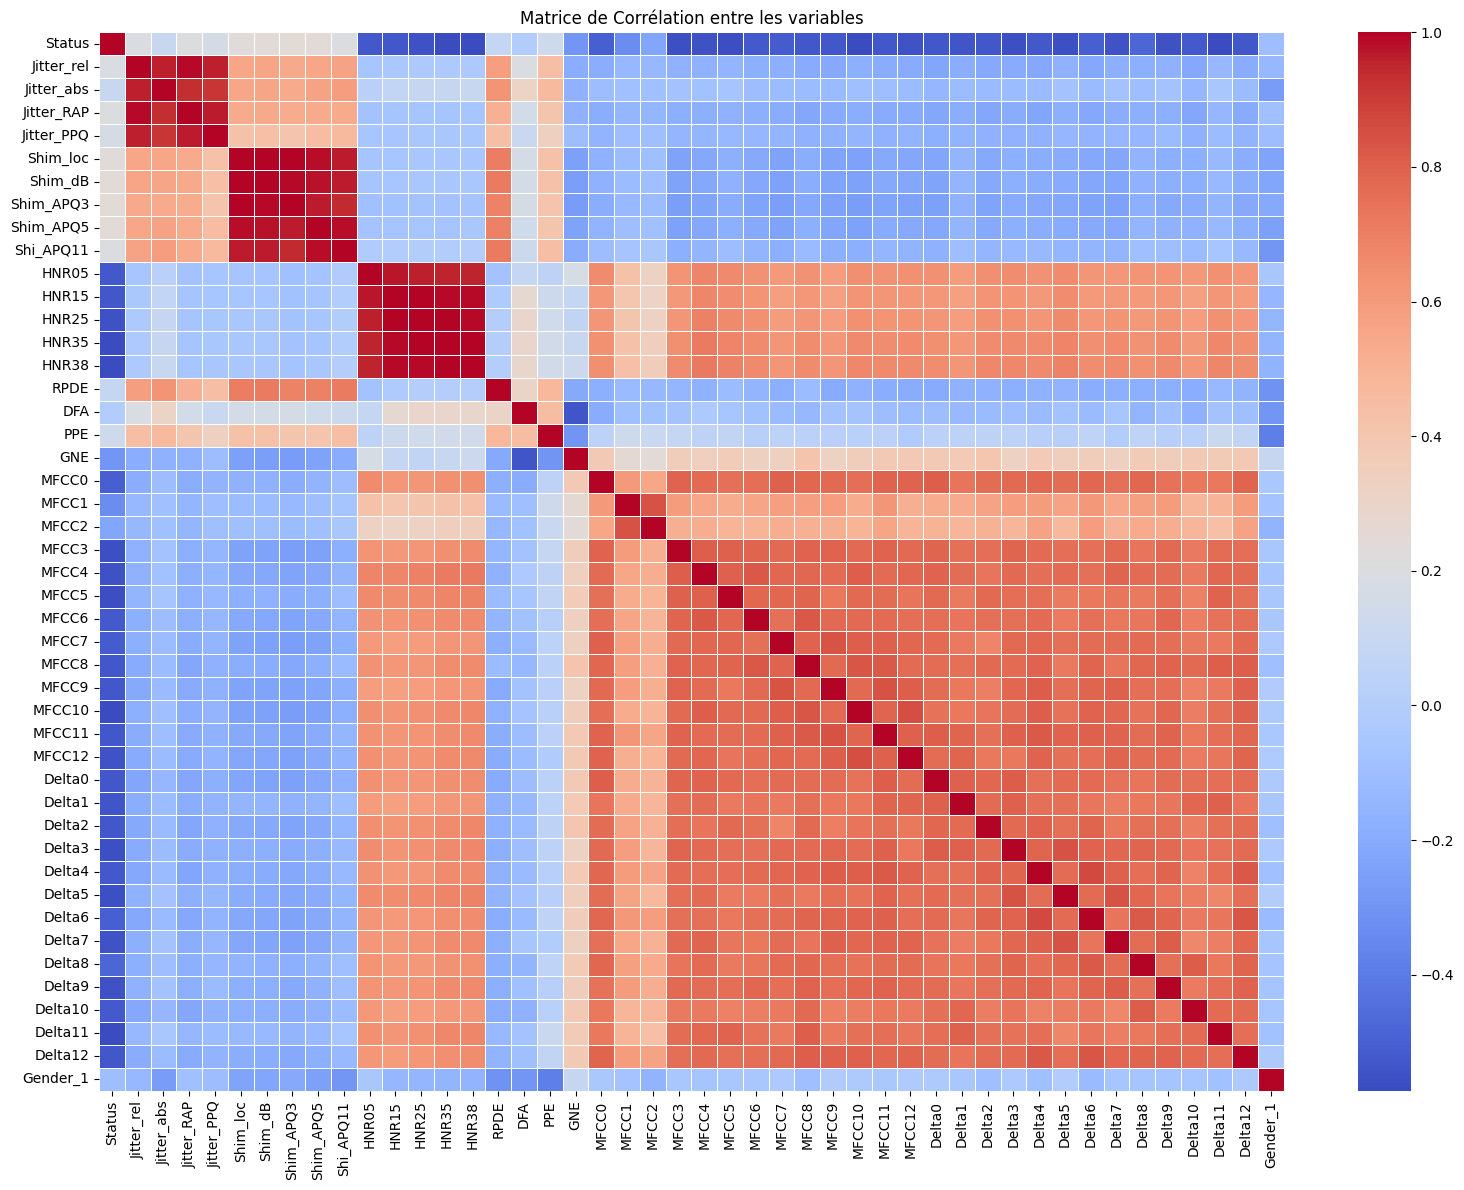

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Chargement du dataset
df = pd.read_csv("parkinson.csv")

# Supprimer les colonnes non numériques ou identifiants
df = df.drop(columns=['ID', 'Recording'])

# Encodage si nécessaire (ex: 'Gender')
df = pd.get_dummies(df, columns=['Gender'], drop_first=True)

# Calcul de la matrice de corrélation
correlation_matrix = df.corr()

# Heatmap avec seaborn
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False, fmt=".2f", linewidths=0.5)
plt.title("Matrice de Corrélation entre les variables")
plt.tight_layout()
plt.show()


1. Sélection de caractéristiques par Information Gain
2. Évaluation des 5 classifieurs
3. Courbe de performance (barplot)

 Évaluation du modèle : Naïve Bayes


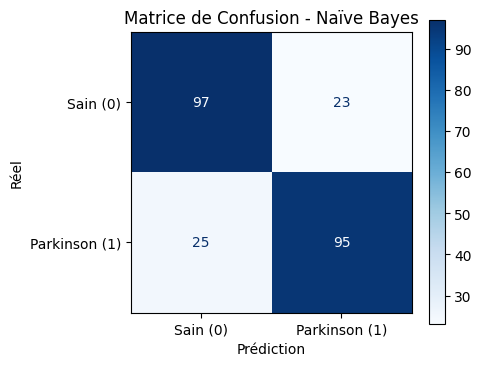


 Rapport de classification - Naïve Bayes
              precision    recall  f1-score   support

           0       0.80      0.81      0.80       120
           1       0.81      0.79      0.80       120

    accuracy                           0.80       240
   macro avg       0.80      0.80      0.80       240
weighted avg       0.80      0.80      0.80       240

--------------------------------------------------------------------------------
 Évaluation du modèle : SVM (C-SVM)


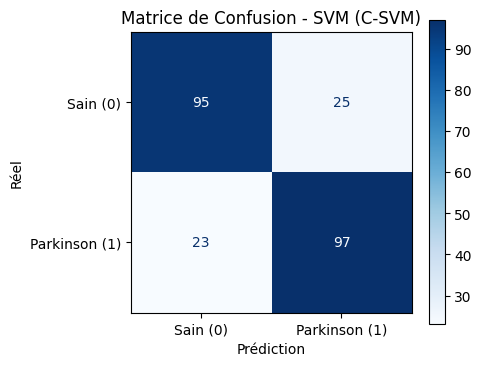


 Rapport de classification - SVM (C-SVM)
              precision    recall  f1-score   support

           0       0.81      0.79      0.80       120
           1       0.80      0.81      0.80       120

    accuracy                           0.80       240
   macro avg       0.80      0.80      0.80       240
weighted avg       0.80      0.80      0.80       240

--------------------------------------------------------------------------------
 Évaluation du modèle : SVM (nu-SVM)


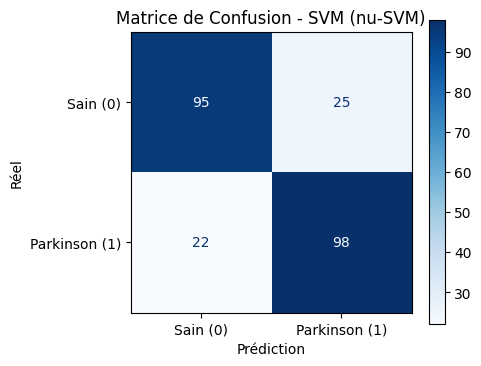


 Rapport de classification - SVM (nu-SVM)
              precision    recall  f1-score   support

           0       0.81      0.79      0.80       120
           1       0.80      0.82      0.81       120

    accuracy                           0.80       240
   macro avg       0.80      0.80      0.80       240
weighted avg       0.80      0.80      0.80       240

--------------------------------------------------------------------------------
 Évaluation du modèle : MLP


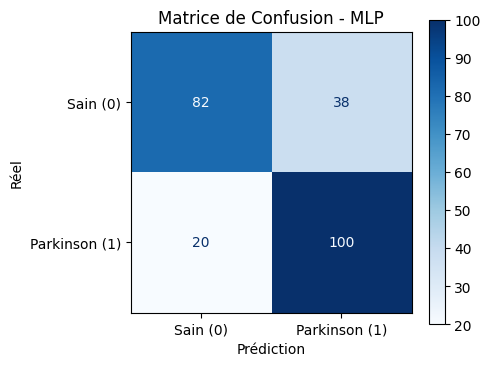


 Rapport de classification - MLP
              precision    recall  f1-score   support

           0       0.80      0.68      0.74       120
           1       0.72      0.83      0.78       120

    accuracy                           0.76       240
   macro avg       0.76      0.76      0.76       240
weighted avg       0.76      0.76      0.76       240

--------------------------------------------------------------------------------
 Évaluation du modèle : KNN


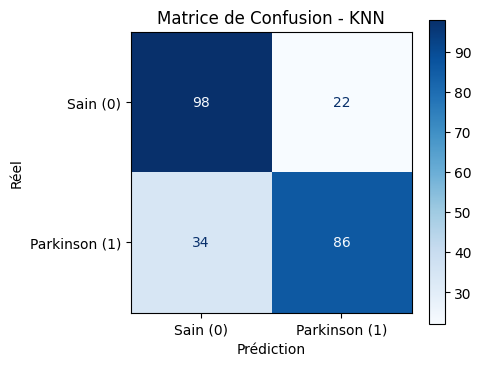


 Rapport de classification - KNN
              precision    recall  f1-score   support

           0       0.74      0.82      0.78       120
           1       0.80      0.72      0.75       120

    accuracy                           0.77       240
   macro avg       0.77      0.77      0.77       240
weighted avg       0.77      0.77      0.77       240

--------------------------------------------------------------------------------
 Évaluation du modèle : Random Forest


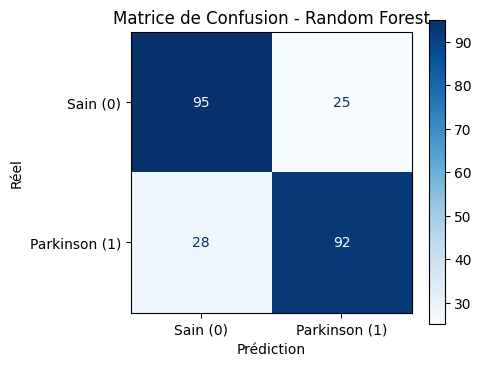


 Rapport de classification - Random Forest
              precision    recall  f1-score   support

           0       0.77      0.79      0.78       120
           1       0.79      0.77      0.78       120

    accuracy                           0.78       240
   macro avg       0.78      0.78      0.78       240
weighted avg       0.78      0.78      0.78       240

--------------------------------------------------------------------------------
 Résultats avec Information Gain + Validation Croisée 10 folds


,Accuracy,Precision,Recall,F1-score
Model,,,,
Naïve Bayes,0.8000,0.8051,0.7917,0.7983
SVM (C-SVM),0.8000,0.7951,0.8083,0.8017
SVM (nu-SVM),0.8042,0.7967,0.8167,0.8066
MLP,0.7583,0.7246,0.8333,0.7752
KNN,0.7667,0.7963,0.7167,0.7544
Random Forest,0.7792,0.7863,0.7667,0.7764


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, NuSVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from IPython.display import display

# 1. Chargement des données
df = pd.read_csv("parkinson.csv")
X = df.drop(columns=['ID', 'Recording', 'Status'])
y = df['Status']
X = pd.get_dummies(X, columns=['Gender'], drop_first=True)

# 2. Sélection des caractéristiques (Information Gain)
selector = SelectKBest(score_func=mutual_info_classif, k=10)
X_selected = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]

# 3. Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

# 4. Validation croisée 10 folds
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 5. Modèles
classifiers = {
    "Naïve Bayes": GaussianNB(),
    "SVM (C-SVM)": SVC(kernel='rbf', probability=True, random_state=42),
    "SVM (nu-SVM)": NuSVC(probability=True, random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(100,),
                         max_iter=2000,
                         early_stopping=True,
                         validation_fraction=0.2,
                         random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=10),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# 6. Évaluation avec validation croisée
results = []
for name, clf in classifiers.items():
    print(f" Évaluation du modèle : {name}")
    y_pred = cross_val_predict(clf, X_scaled, y, cv=cv)
    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

    # Affichage de la matrice de confusion
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=["Sain (0)", "Parkinson (1)"])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(cmap='Blues', ax=ax, colorbar=True)
    plt.title(f"Matrice de Confusion - {name}")
    plt.xlabel("Prédiction")
    plt.ylabel("Réel")
    plt.grid(False)
    plt.tight_layout()
    plt.show()


    # Rapport détaillé
    print(f"\n Rapport de classification - {name}")
    print(classification_report(y, y_pred))
    print("-" * 80)

# Résumé global des performances
results_df = pd.DataFrame(results).set_index("Model").round(4)
print(" Résultats avec Information Gain + Validation Croisée 10 folds")
display(results_df)




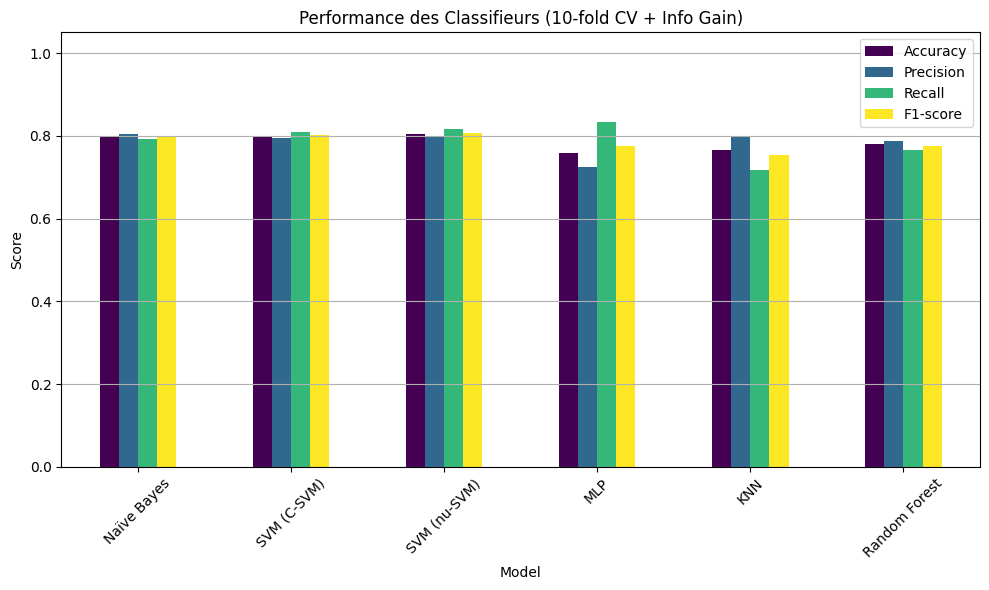

: 

In [ ]:

# 8. Barplot comparatif
results_df.plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title("Performance des Classifieurs (10-fold CV + Info Gain)")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()